# 🌍 Climate Risk & Environmental Impact Analysis

## Section 1: Dataset Introduction

### About the Dataset

The dataset used in this project is the **Global Climate Risk & Environmental 
Impact Dataset**, sourced from Kaggle. It contains country-level climate data 
including CO₂ emissions, temperature change, sea level rise, flood/drought risk 
levels, and a composite climate risk score.

- **Granularity:** Country-Year level  
- **Target Variables:** `climate_risk_score`, `population_affected_m`

---

### Why This Dataset

- Climate change has direct, measurable impact on populations worldwide  
- The dataset supports multiple ML tasks — regression, classification, and clustering  
- Features are interpretable, making SHAP-based explainability meaningful  

---

### Problem Statement

> Can we predict a country's climate risk score and affected population 
> using environmental indicators — and identify which factors matter most?

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("global_climate_change_extreme_weather_2026.csv")

In [37]:
df.head(4)

,record_id,country,region,avg_temperature_c,temperature_change_c,co2_emissions_mt,sea_level_rise_mm,flood_risk,drought_risk,heatwave_days,wildfire_incidents,rainfall_change_mm,air_quality_index,climate_risk_score,population_affected_m,year
0,CLM0001,Canada,North America,16.8,2.40,5477,1.44,Low,High,9,25,-117,127,89,92.7,2026
1,CLM0002,Brazil,South America,28.8,1.51,3758,1.55,Medium,Medium,38,197,73,103,81,95.4,2026
2,CLM0003,Australia,Oceania,6.6,1.70,1904,5.81,Medium,Medium,20,161,127,253,71,32.0,2026
3,CLM0004,Germany,Europe,10.9,1.53,3786,5.41,Medium,Low,56,191,-57,166,57,131.5,2026


In [38]:
print(f"Rows and coloumns in data {df.shape}")
df.dtypes
 

Rows and coloumns in data (5000, 16)


record_id                 object
country                   object
region                    object
avg_temperature_c        float64
temperature_change_c     float64
co2_emissions_mt           int64
sea_level_rise_mm        float64
flood_risk                object
drought_risk              object
heatwave_days              int64
wildfire_incidents         int64
rainfall_change_mm         int64
air_quality_index          int64
climate_risk_score         int64
population_affected_m    float64
year                       int64
dtype: object

In [39]:
print(f"Duplicated values are  {df.duplicated().sum()}")
df.isnull().sum()

Duplicated values are  0


record_id                0
country                  0
region                   0
avg_temperature_c        0
temperature_change_c     0
co2_emissions_mt         0
sea_level_rise_mm        0
flood_risk               0
drought_risk             0
heatwave_days            0
wildfire_incidents       0
rainfall_change_mm       0
air_quality_index        0
climate_risk_score       0
population_affected_m    0
year                     0
dtype: int64

In [40]:
print(f"Info about data {df.info()}")

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   record_id              5000 non-null   object 
 1   country                5000 non-null   object 
 2   region                 5000 non-null   object 
 3   avg_temperature_c      5000 non-null   float64
 4   temperature_change_c   5000 non-null   float64
 5   co2_emissions_mt       5000 non-null   int64  
 6   sea_level_rise_mm      5000 non-null   float64
 7   flood_risk             5000 non-null   object 
 8   drought_risk           5000 non-null   object 
 9   heatwave_days          5000 non-null   int64  
 10  wildfire_incidents     5000 non-null   int64  
 11  rainfall_change_mm     5000 non-null   int64  
 12  air_quality_index      5000 non-null   int64  
 13  climate_risk_score     5000 non-null   int64  
 14  population_affected_m  5000 non-null   float64
 15  year

,avg_temperature_c,temperature_change_c,co2_emissions_mt,sea_level_rise_mm,heatwave_days,wildfire_incidents,rainfall_change_mm,air_quality_index,climate_risk_score,population_affected_m,year
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.0
mean,17.491040,1.493576,3145.744600,3.49663,32.407400,148.337800,0.881200,175.280200,57.60100,150.177160,2026.0
std,7.203599,0.576416,1640.113354,1.42864,16.263343,87.615102,86.708135,72.615251,22.02999,86.287074,0.0
min,5.000000,0.500000,301.000000,1.00000,5.000000,0.000000,-150.000000,50.000000,20.00000,1.100000,2026.0
25%,11.300000,0.990000,1708.750000,2.26000,18.000000,70.000000,-73.000000,112.000000,39.00000,78.200000,2026.0
50%,17.400000,1.480000,3173.000000,3.52000,32.000000,149.000000,2.000000,175.000000,58.00000,149.750000,2026.0
75%,23.800000,1.990000,4552.500000,4.74000,47.000000,223.000000,76.000000,239.000000,77.00000,225.025000,2026.0
max,30.000000,2.500000,5999.000000,6.00000,60.000000,300.000000,150.000000,300.000000,95.00000,300.000000,2026.0


In [41]:
df["flood_risk"].value_counts()

flood_risk
Low       1731
Medium    1670
High      1599
Name: count, dtype: int64

In [42]:
df.tail(2)

,record_id,country,region,avg_temperature_c,temperature_change_c,co2_emissions_mt,sea_level_rise_mm,flood_risk,drought_risk,heatwave_days,wildfire_incidents,rainfall_change_mm,air_quality_index,climate_risk_score,population_affected_m,year
4998,CLM4999,China,Asia,13.7,0.71,3978,3.46,High,Medium,6,89,51,83,94,201.5,2026
4999,CLM5000,United Kingdom,Europe,7.2,2.45,2397,4.42,Low,Medium,52,287,23,152,49,19.1,2026


In [43]:
df.sample(2)

,record_id,country,region,avg_temperature_c,temperature_change_c,co2_emissions_mt,sea_level_rise_mm,flood_risk,drought_risk,heatwave_days,wildfire_incidents,rainfall_change_mm,air_quality_index,climate_risk_score,population_affected_m,year
2417,CLM2418,Pakistan,Asia,16.9,1.58,2761,1.44,High,Low,16,168,38,266,65,127.9,2026
2209,CLM2210,Germany,Europe,27.6,2.24,1890,4.52,High,High,22,278,114,259,65,282.8,2026


In [44]:
df.columns.to_list()

['record_id',
 'country',
 'region',
 'avg_temperature_c',
 'temperature_change_c',
 'co2_emissions_mt',
 'sea_level_rise_mm',
 'flood_risk',
 'drought_risk',
 'heatwave_days',
 'wildfire_incidents',
 'rainfall_change_mm',
 'air_quality_index',
 'climate_risk_score',
 'population_affected_m',
 'year']

Unique values per column:
record_id                5000
country                    10
region                      6
avg_temperature_c         251
temperature_change_c      201
co2_emissions_mt         3315
sea_level_rise_mm         501
flood_risk                  3
drought_risk                3
heatwave_days              56
wildfire_incidents        301
rainfall_change_mm        301
air_quality_index         251
climate_risk_score         76
population_affected_m    2440
year                        1
dtype: int64
Regions: ['North America' 'South America' 'Oceania' 'Europe' 'Africa' 'Asia']

Correlation Matrix:
                       avg_temperature_c  temperature_change_c  \
avg_temperature_c               1.000000              0.015986   
temperature_change_c            0.015986              1.000000   
co2_emissions_mt                0.009456              0.020502   
sea_level_rise_mm               0.002782              0.005516   
heatwave_days                   0.008140            

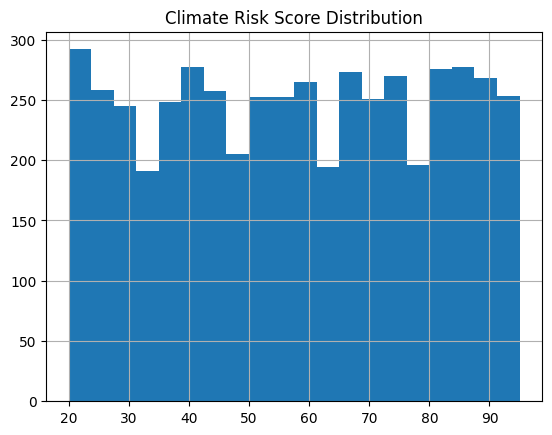


Average by Region:
               avg_temperature_c  temperature_change_c  co2_emissions_mt  \
region                                                                     
Africa                 17.333745              1.531317       3050.681070   
Asia                   17.540124              1.481989       3174.467997   
Europe                 17.593852              1.519798       3125.496638   
North America          17.693888              1.483357       3166.562124   
Oceania                17.017729              1.492968       3125.243028   
South America          17.362692              1.458385       3174.705769   

               sea_level_rise_mm  heatwave_days  wildfire_incidents  \
region                                                                
Africa                  3.454897      32.833333          144.687243   
Asia                    3.484563      32.602202          145.653131   
Europe                  3.489385      32.292988          149.955812   
North America   

flood_risk,High,Low,Medium
region,,,
Africa,58.466667,58.271676,56.871622
Asia,58.525275,57.877339,58.313346
Europe,57.328221,55.137662,58.536364
North America,59.482315,55.736196,58.725762
Oceania,56.168605,59.039548,58.555556
South America,55.729412,53.920635,58.422360


In [ ]:
# ── Section 2:  unique values of data set

print("Unique values per column:")
print(df.nunique())

# 6. Unique values in categorical columns
print("Regions:", df['region'].unique())

# 7. Correlation matrix
print("\nCorrelation Matrix:")
print(df.corr(numeric_only=True))

# 8. Distribution of key numeric columns
df['climate_risk_score'].hist(bins=20)
plt.title('Climate Risk Score Distribution')
plt.show()


# 9. Average values by region
print("\nAverage by Region:")
print(df.groupby('region').mean(numeric_only=True))

# 10. 

print(df['drought_risk'].value_counts(normalize=True))

# 11. All categorical columns
print(df.select_dtypes(include='object'))

# 12. Countries with 'High' flood risk count
print(df['flood_risk'].str.contains('High').sum())

# 13. Top 5 countries by climate 
print(df.sort_values('climate_risk_score', ascending=False).head(5))

# 14. High risk countries 
print(df[df['climate_risk_score'] > 80])

# 15. Pivot — avg climate risk score 
pd.pivot_table(df, values='climate_risk_score', 
               index='region', 
               columns='flood_risk', 
               aggfunc='mean')

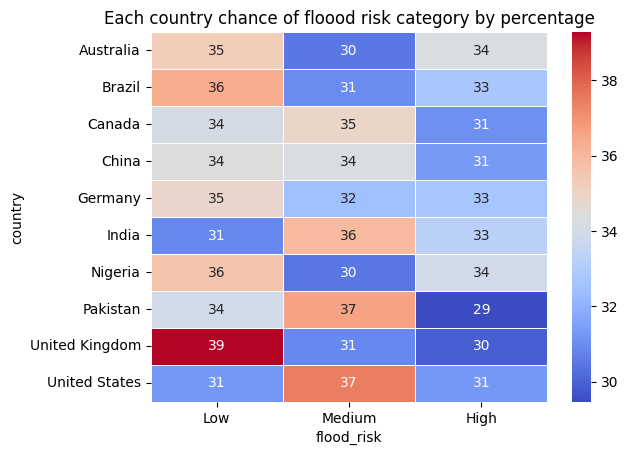

In [46]:
# df["country"].value_counts()

temp_df= round(pd.crosstab(df["country"],df["flood_risk"],normalize="index")*100,2)
index = ["Low","Medium","High"]
temp_df = temp_df[index]
sns.heatmap(temp_df,annot=True,linewidths=0.5,cmap="coolwarm")
plt.title("Each country chance of floood risk category by percentage")
plt.show()

C:\Users\Zainch-032\AppData\Local\Temp\ipykernel_4436\3730110918.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=x, x="country", y="population_affected_m",palette="magma")


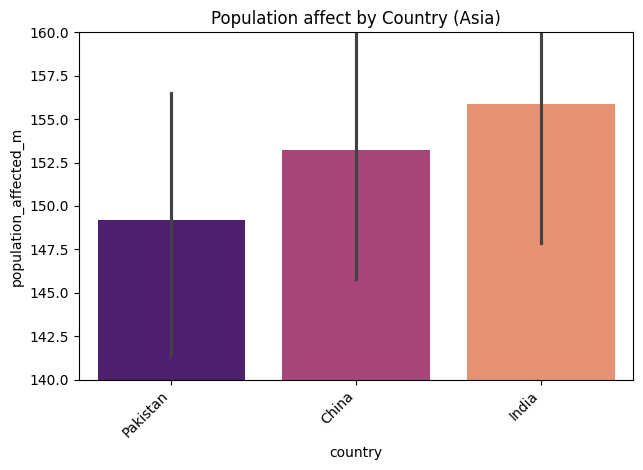

,record_id,country,region,avg_temperature_c,temperature_change_c,co2_emissions_mt,sea_level_rise_mm,flood_risk,drought_risk,heatwave_days,wildfire_incidents,rainfall_change_mm,air_quality_index,climate_risk_score,population_affected_m,year
0,CLM0001,Canada,North America,16.8,2.40,5477,1.44,Low,High,9,25,-117,127,89,92.7,2026
1,CLM0002,Brazil,South America,28.8,1.51,3758,1.55,Medium,Medium,38,197,73,103,81,95.4,2026


In [47]:
x = df[df["region"].str.contains("Asia")]

sns.barplot(data=x, x="country", y="population_affected_m",palette="magma")
plt.xticks(rotation=45, ha='right')
plt.title("Population affect by Country (Asia)")
plt.tight_layout()
plt.ylim(140,160)
plt.show()
df.head(2)

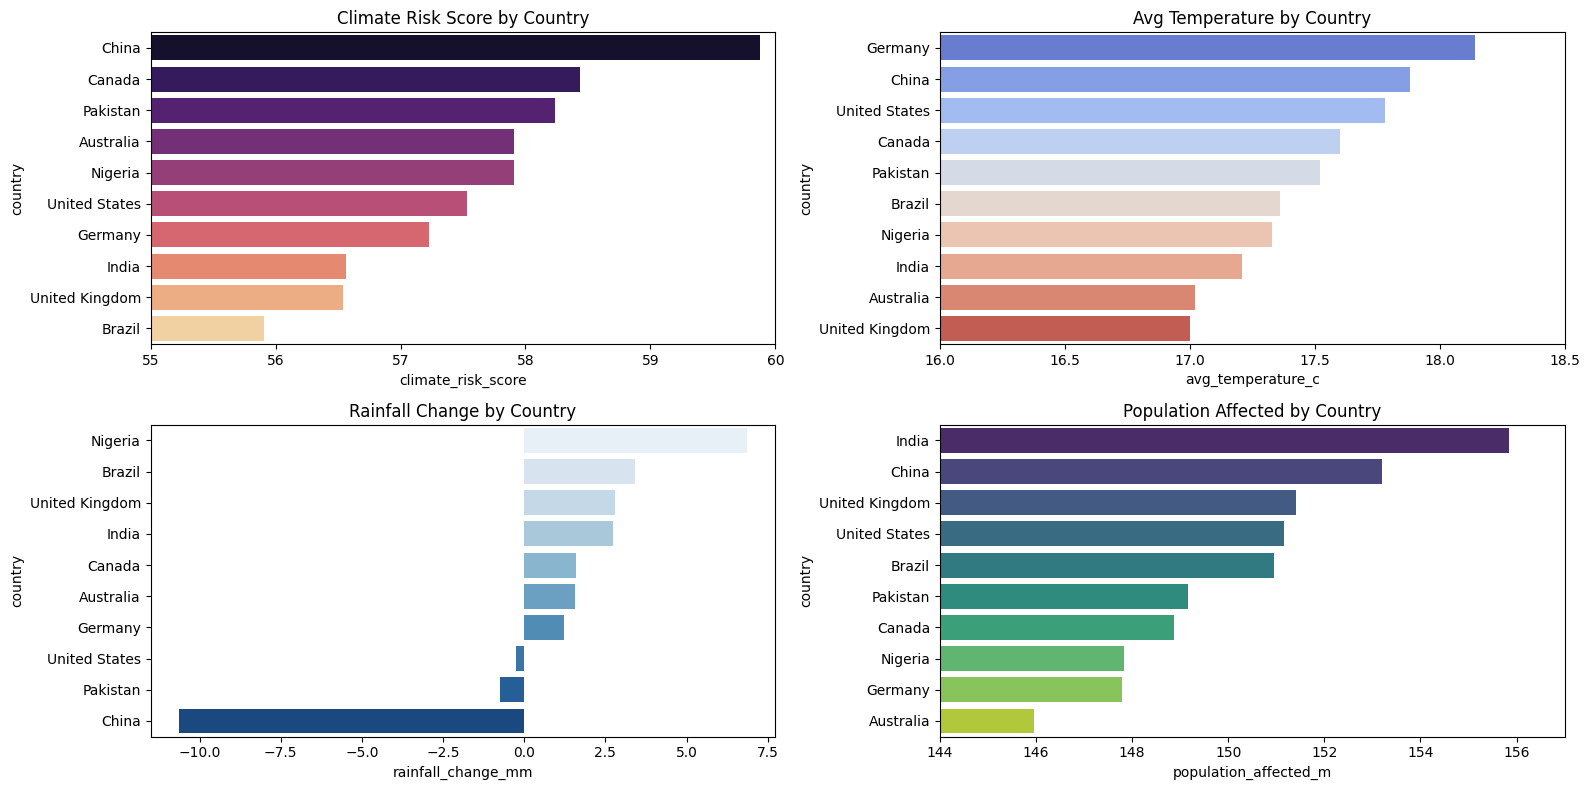

In [49]:
x = round(df.groupby("country")[["climate_risk_score","avg_temperature_c","rainfall_change_mm","population_affected_m"]].mean(),2)

x_sort = x.sort_values(by="climate_risk_score",ascending=False)
y_sort = x.sort_values(by="avg_temperature_c",ascending=False)
z_sort = x.sort_values(by="rainfall_change_mm",ascending=False)
a_sort = x.sort_values(by="population_affected_m",ascending=False)
fig,axes = plt.subplots(2,2,figsize=(16,8))

sns.barplot(data=x_sort, x="climate_risk_score", y="country", 
            ax=axes[0,0], hue="country", palette="magma", legend=False)
axes[0,0].set_xlim(55,60)
axes[0,0].set_title("Climate Risk Score by Country")

sns.barplot(data=y_sort, x="avg_temperature_c", y="country", 
            ax=axes[0,1], hue="country", palette="coolwarm", legend=False)
axes[0,1].set_xlim(16,18.5)
axes[0,1].set_title("Avg Temperature by Country")

sns.barplot(data=z_sort, x="rainfall_change_mm", y="country", 
            ax=axes[1,0], hue="country", palette="Blues", legend=False)
# axes[0,0].set_xlim(54,60)
axes[1,0].set_title("Rainfall Change by Country")

sns.barplot(data=a_sort, x="population_affected_m", y="country", 
            ax=axes[1,1], hue="country", palette="viridis", legend=False)
axes[1,1].set_xlim(144,157)
axes[1,1].set_title("Population Affected by Country")

plt.tight_layout()
plt.show()

**3 Key Findings:**

1. **China has the highest climate risk score**, but it's not the hottest country — meaning risk score depends on multiple factors, not just temperature.

2. **India has the highest population affected** (~156M), even though its risk score is only moderate — showing that risk and human impact don't always match.

3. **China has the worst rainfall decline** (drought trend), while **Nigeria has the highest rainfall increase** (flood trend) — showing opposite climate stress patterns across countries.